# Load libraries

**NOTE**: `tensorflow` and `keras` are *only* used to be able to import the MNIST dataset

In [1]:
import numpy as np
import matplotlib.pyplot as PLT

from scipy.special import softmax,logsumexp

import tensorflow as tf
from tensorflow import keras

Duplicate key in file '/Users/nelsondiaz/.matplotlib/matplotlibrc', line 2 ('backend: GTK3Cairo')


# Download data

In [2]:
from tensorflow.keras.datasets import mnist

# Training / validation data + labels
(x_train, y_train), (x_valid, y_valid) = mnist.load_data()

print('Shape (training data):', x_train.shape)
print('Shape (valid/testing data):', x_valid.shape)


Shape (training data): (60000, 28, 28)
Shape (valid/testing data): (10000, 28, 28)


### Data pre-processing (normalization, etc.)

In [3]:
def stdPreproc(dIn,L=255.0, flagNorm=True, flagMean=True):

    dIn = dIn.astype("float")
    
    if flagNorm:
       dIn = dIn/L

    if flagMean:
       mean = np.mean(dIn, axis = 0)
       dIn -= mean
    
    return(dIn)

x_train = stdPreproc(x_train)
x_valid = stdPreproc(x_valid)

#### Visualization of a random element

Shape: (28, 28) label: 0


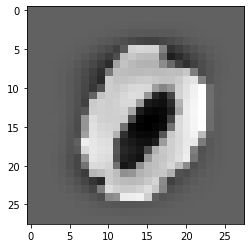

In [4]:
k = np.random.randint(0,x_train.shape[0])
    
PLT.imshow(x_train[k], cmap='gray')
print('Shape:',x_train[k].shape, 'label:', y_train[k])


#### Data vectorization

In [5]:
x_train = np.transpose( x_train.reshape(x_train.shape[0], x_train.shape[1]*x_train.shape[2]) )
x_valid = np.transpose( x_valid.reshape(x_valid.shape[0], x_valid.shape[1]*x_valid.shape[2]) )

# NOTE: in order to be consistant with lectures, then these matrices must be transpose


# Functions

Some useful functions are included here. For a full explanation see **Lecture 3b's Introduction**.

In [6]:
def softmax_L2_cost(X, Y, W, lmbd):

    fCost = np.sum(np.log(np.sum(np.exp(-X.transpose().dot(W)), axis=1)))
    fCost += np.sum( X*W[:,Y] )
    
    fCost /= float(X.shape[1])
    
    if lmbd > 0:
       fCost += lmbd*(sum( np.power(W.ravel(),2) ))
    
    return fCost

def softmax_L2_grad(X, Y, W, n, lmbd):
    
    z = X[:,np.ix_(n)].squeeze(1)      # select batch elements

    g = -z.dot( softmax(-z.transpose().dot(W),axis=1) )
    
    for k in range(len(n)):
        g[:,Y[n[k]] ] += z[:,k] 

    g /= float(len(n))  
    
    if lmbd > 0:
       g += lmbd*W
        
    return g
    
    
softmax_cost = lambda X,Y,W : softmax_L2_cost(X, Y, W, 0.)

softmax_grad = lambda X,Y,W,n : softmax_L2_grad(X, Y, W, n, 0.)
    
    

In [7]:
def computeSuccessSoftMax(X, Y, W):

    clase = -np.matmul(X.transpose(), W) 
    success = sum( np.argmax(clase,axis=1) == Y )
                
    return float(success)/float(X.shape[1])    
        
    

___

## Routines for SGD and variants

In [8]:


ssCte = lambda xx, kk : xx  # identity

def ssSqrtDec(alpha0,k):
    
    if k > 0:
       alpha = alpha0/np.sqrt(k)
    else:
       alpha = alpha0
    
    return(alpha)
    
# Assumes that NetArch is a dictionary
def stochGD(X, Y, nEpochs, NetArch, alpha0=0.01, blkSize=32, extraPar={}):
    
    W = 0.01*np.random.randn(X.shape[0], NetArch['nClass'])
    
    fCost = np.zeros( (1,2) )
    fCost[0,1] = NetArch['cost'](X,Y,W)
    
    flagVerbose = extraPar.get('flagVerbose', 0) 
    k = -1
    nBlk = np.floor_divide(X.shape[1],blkSize)         
    
    for e in range(nEpochs):

      if flagVerbose > 0:  
         print('\n')
         print("="*10)
         print('Epoch', e)
         print("="*10,'\n')
    
      # Generate permutation
      blkInd = 0
      perm = np.random.permutation(X.shape[1])
     
      last  = 0
      if np.remainder(X.shape[1],blkSize) > 0:
         last = 1 
                
      for b in range(nBlk):
        
        # general iteration counter
        k += 1
        
        # selec indexex
        n = perm[blkInd:blkInd+blkSize]
        blkInd += blkSize
        
        # step-size Policy
        ssPolicy = extraPar.get('lrPolicy', ssCte)
        alpha = ssPolicy(alpha0,k)
        
        # Compute the gradient
        g = NetArch['grad'](X, Y, W, n)
        
        # GD step
        W = W - alpha*g                     # In general
                                            # NetArch['prox'](W - alpha*g, alpha, lmbd)
        
        flagVerbose = extraPar.get('flagVerbose', 0)    
        if flagVerbose > 0:
          if np.remainder(k,flagVerbose) == 0:
           
            kCost = np.array([k, NetArch['cost'](X,Y,W)])
            fCost = np.append(fCost, kCost[np.newaxis,...], axis=0)
            print('Iter', k, '  cost ', fCost[-1,1])
            if 'accuracy' in NetArch.keys():
              print('Success rate:', NetArch['accuracy'](W) )
                
      if last == 1:  

        # general iteration counter
        k += 1
        
        # selec indexex
        n = perm[blkInd:X.shape[1]]
        
        g = NetArch['grad'](X, Y, W, n)
        W = W - alpha*g
    
    
    return(W, fCost)  


def adaGrad(X, Y, nEpochs, NetArch, alpha0=0.01, blkSize=32, flagVerbose=10, extraPar={}):
    
    W = 0.01*np.random.randn(X.shape[0], NetArch['nClass'])
    
    fCost = np.zeros( (1,2) )
    fCost[0,1] = NetArch['cost'](X,Y,W)
    
    flagVerbose = extraPar.get('flagVerbose', 0) 
    k = -1
    nBlk = np.floor_divide(X.shape[1],blkSize)         
    
    # -----
    v = 0
    # -----
    
    for e in range(nEpochs):

      if flagVerbose > 0:  
         print('\n')
         print("="*10)
         print('Epoch', e)
         print("="*10,'\n')
    
      # Generate permutation
      blkInd = 0
      perm = np.random.permutation(X.shape[1])
     
      last  = 0
      if np.remainder(X.shape[1],blkSize) > 0:
         last = 1 
                
      for b in range(nBlk):
        
        # general iteration counter
        k += 1
        
        # selec indexex
        n = perm[blkInd:blkInd+blkSize]
        blkInd += blkSize
        
        # Compute the gradient
        g = NetArch['grad'](X, Y, W, n)
        
        # step-size Policy
        ssPolicy = extraPar.get('lrPolicy', ssCte)
        alpha = ssPolicy(alpha0, k)
        
        # step-size correction (AdaGrad)
        v = v + g*g
        w = 1./np.sqrt(extraPar['epsilon']+v)
        
        # GD step
        W = W - alpha*w*g                   # In general
                                            # NetArch['prox'](W - alpha*g, alpha, lmbd)

        if flagVerbose > 0:
          if np.remainder(k,flagVerbose) == 0:
           
            kCost = np.array([k, NetArch['cost'](X,Y,W)])
            fCost = np.append(fCost, kCost[np.newaxis,...], axis=0)
            print('Iter', k, '  cost ', fCost[-1,1])
            if 'accuracy' in NetArch.keys():
              print('Success rate:', NetArch['accuracy'](W) )
                
      if last == 1:  

        # general iteration counter
        k += 1
        
        # selec indexex
        n = perm[blkInd:X.shape[1]]
        
        g = NetArch['grad'](X, Y, W, n)
        W = W - alpha*g
    
    
    return(W, fCost)  

def Adam(X, Y, nEpochs, NetArch, alpha0=0.01, blkSize=32, flagVerbose=10, extraPar={}):
    
    W = 0.01*np.random.randn(X.shape[0], NetArch['nClass'])
    
    fCost = np.zeros( (1,2) )
    fCost[0,1] = NetArch['cost'](X,Y,W)
    
    flagVerbose = extraPar.get('flagVerbose', 0) 
    gamma1  = extraPar.get('gamma1', 0.9)
    gamma2  = extraPar.get('gamma2', 0.999)
    epsilon = extraPar.get('epsilon', 1e-7)
    
    k = -1
    nBlk = np.floor_divide(X.shape[1],blkSize)         
    
    # -----
    v = 0
    T = 0
    # -----
    
    for e in range(nEpochs):

      if flagVerbose > 0:  
         print('\n')
         print("="*10)
         print('Epoch', e)
         print("="*10,'\n')
    
      # Generate permutation
      blkInd = 0
      perm = np.random.permutation(X.shape[1])
     
      last  = 0
      if np.remainder(X.shape[1],blkSize) > 0:
         last = 1 
                
      for b in range(nBlk):
        
        # general iteration counter
        k += 1
        
        # selec indexex
        n = perm[blkInd:blkInd+blkSize]
        blkInd += blkSize
        
        # Compute the gradient
        g = NetArch['grad'](X, Y, W, n)
        
        # step-size Policy
        ssPolicy = extraPar.get('lrPolicy', ssCte)
        alpha = ssPolicy(alpha0, k)
        
        # step-size correction (AdaGrad)
        v = gamma2*v + (1-gamma2)*g*g
        if k>0:
           w = (np.sqrt(1-gamma2**k)/(1-gamma1**k))*(1./(np.sqrt(v)+epsilon))
        else:
           w = (1./(np.sqrt(v)+epsilon))
        
        # GD step
        T = gamma1*T + (1-gamma1)*g
        W = W - alpha*w*T                   # In general
                                            # NetArch['prox'](W - alpha*g, alpha, lmbd)

        if flagVerbose > 0:
          if np.remainder(k,flagVerbose) == 0:
           
            kCost = np.array([k, NetArch['cost'](X,Y,W)])
            fCost = np.append(fCost, kCost[np.newaxis,...], axis=0)
            print('Iter', k, '  cost ', fCost[-1,1])
            if 'accuracy' in NetArch.keys():
              print('Success rate:', NetArch['accuracy'](W) )
                
      if last == 1:  

        # general iteration counter
        k += 1
        
        # selec indexex
        n = perm[blkInd:X.shape[1]]
        
        g = NetArch['grad'](X, Y, W, n)
        W = W - alpha*g
    
    
    return(W, fCost)  



## Case 1 (NetArch is a dictionary)



Epoch 0

Iter 0   cost  2.3013380360009754
Success rate: 0.1273
Iter 100   cost  2.1914511488085195
Success rate: 0.4884
Iter 200   cost  2.091856373982155
Success rate: 0.6413
Iter 300   cost  2.000111373847542
Success rate: 0.6921
Iter 400   cost  1.9147557366595451
Success rate: 0.7155
Iter 500   cost  1.835130893808122
Success rate: 0.7253
Iter 600   cost  1.76252538064459
Success rate: 0.734
Iter 700   cost  1.6964753174626388
Success rate: 0.7428
Iter 800   cost  1.635414793770312
Success rate: 0.7498
Iter 900   cost  1.5783064374110507
Success rate: 0.7542
Iter 1000   cost  1.5264751155716465
Success rate: 0.7591
Iter 1100   cost  1.4793026112549739
Success rate: 0.7645
Iter 1200   cost  1.4350612916979117
Success rate: 0.768
Iter 1300   cost  1.3940241116508254
Success rate: 0.771
Iter 1400   cost  1.3559485578822694
Success rate: 0.7739
Iter 1500   cost  1.3207550746005994
Success rate: 0.7769
Iter 1600   cost  1.2886459342516279
Success rate: 0.7809
Iter 1700   cost  1.2584

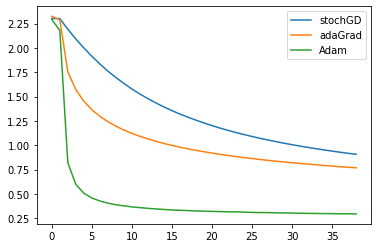

In [9]:
fI = lambda xx, yy, zz : xx  # identity

testSucess = lambda W : computeSuccessSoftMax(x_valid, y_valid, W)

Fsoftmax = {'cost': softmax_cost, 'grad':softmax_grad, 'hidden':None, 'prox':fI, 'nClass':10, 'accuracy':testSucess}

W = []
statsSGD = []
sgdVariant = {'stochGD':stochGD,'adaGrad':adaGrad,'Adam':Adam}

epSGD={'lrPolicy':ssCte,'flagVerbose':100}
epAdaGrad={'epsilon':1e-7,'lrPolicy':ssCte,'flagVerbose':100}
epAdam={'epsilon':1e-7,'gamma1':0.9,'gamma2':0.999,'flagVerbose':100,'lrPolicy':ssCte}

extraParList = [epSGD, epAdaGrad, epAdam]


for k, routine in enumerate(sgdVariant.keys()): 
    weights, cost = sgdVariant[routine](x_train, y_train, 2, Fsoftmax, alpha0=0.001, blkSize=32, extraPar=extraParList[k])
    W.append(weights)
    statsSGD.append(cost)
    
PLT.figure()
for k, keys in enumerate(sgdVariant): 
    PLT.plot(statsSGD[k][:,1], label=r'{0}'.format(keys) )
PLT.legend(loc='upper right')